In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuración de reproducibilidad
np.random.seed(42)
n_rows = 2500

# 1. GENERACIÓN DE VARIABLES BASE
# Edad (Media ~49)
age = np.random.randint(18, 80, size=n_rows)
# Precio unitario (Distribución base 10-500)
unit_price = np.random.uniform(10, 500, size=n_rows)
# Unidades vendidas (1 a 10)
units_sold = np.random.randint(1, 11, size=n_rows)

# 2. CREACIÓN DE CORRELACIONES (Señales reales para Pearson)
# Correlación POSITIVA fuerte: Revenue depende de Unit_Price
# (Precio * Unidades + un poco de ruido aleatorio)
revenue = (unit_price * units_sold) + np.random.normal(0, 15, n_rows)

# Correlación NEGATIVA moderada: Rating vs Edad 
# Simulamos que a mayor edad, el rating tiende a ser más bajo (o más exigente)
rating = 5.5 - (age / 20) + np.random.normal(0, 0.5, n_rows)
rating = np.clip(rating, 1, 5) # Forzar rango de estrellas 1-5

# Correlación CERO: Shipping_Cost vs Unit_Price
# El costo de envío es aleatorio y no depende del valor del producto
shipping_cost = np.random.uniform(5, 100, size=n_rows)

# 3. CONSTRUCCIÓN DEL DATAFRAME (Headers Limpios)
data = {
    'Transaction_ID': range(5000, 5000 + n_rows),
    'Date': pd.date_range(start='2024-01-01', periods=n_rows, freq='H'),
    'Customer_Age': age.astype(float),
    'Product_Category': np.random.choice(['Electronics', 'Clothing', 'Home', 'Books', 'Toys'], n_rows),
    'Country': np.random.choice(['USA', 'Canada', 'UK', 'Germany', 'France'], n_rows, p=[0.5, 0.15, 0.15, 0.1, 0.1]),
    'Units_Sold': units_sold,
    'Unit_Price': unit_price,
    'Shipping_Cost': shipping_cost,
    'Rating': rating,
    'Total_Revenue': revenue
}

df = pd.DataFrame(data)

# 4. INSERCIÓN DE INCONSISTENCIAS Y "ERRORES" (Basado en Slides)

# A. Falta de estandarización en Categorías (USA y Electronics)
# USA con espacios, minúsculas y puntos
usa_variants = [' USA', 'usa ', 'U.S.A.', 'united states']
df.loc[df['Country'] == 'USA', 'Country'] = np.random.choice(usa_variants, size=len(df[df['Country'] == 'USA']))

# Electronics con inconsistencias de formato
elect_variants = ['ELECTRONICS', 'electronics', ' Elect. ', 'Electronic']
df.loc[df['Product_Category'] == 'Electronics', 'Product_Category'] = np.random.choice(elect_variants, size=len(df[df['Product_Category'] == 'Electronics']))

# B. Outliers (1% de los datos con precios extremos para IQR)
outlier_idx = df.sample(frac=0.01).index
df.loc[outlier_idx, 'Unit_Price'] = df.loc[outlier_idx, 'Unit_Price'] * 25 # Precios de hasta $12,500

# C. Valores Nulos (Missing Values para isna.sum() y fillna)
df.loc[df.sample(frac=0.05).index, 'Customer_Age'] = np.nan
df.loc[df.sample(frac=0.03).index, 'Rating'] = np.nan

# D. Duplicados exactos (Para duplicated y drop_duplicates)
df = pd.concat([df, df.iloc[:50]], ignore_index=True)

# 5. EXPORTAR A CSV
file_name = 'BI_Class_2_eda.csv'
df.to_csv(file_name, index=False)

print(f"Dataset '{file_name}' generado exitosamente.")
print(f"Filas totales (incluyendo duplicados): {len(df)}") 



Dataset 'BI_Class_2_eda.csv' generado exitosamente.
Filas totales (incluyendo duplicados): 2550


C:\Users\USER\AppData\Local\Temp\ipykernel_24640\3613567156.py:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'Date': pd.date_range(start='2024-01-01', periods=n_rows, freq='H'),


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2550 entries, 0 to 2549
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction_ID    2550 non-null   int64         
 1   Date              2550 non-null   datetime64[ns]
 2   Customer_Age      2424 non-null   float64       
 3   Product_Category  2550 non-null   object        
 4   Country           2550 non-null   object        
 5   Units_Sold        2550 non-null   int32         
 6   Unit_Price        2550 non-null   float64       
 7   Shipping_Cost     2550 non-null   float64       
 8   Rating            2475 non-null   float64       
 9   Total_Revenue     2550 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int32(1), int64(1), object(2)
memory usage: 189.4+ KB


In [6]:
100*df.isna().mean().sort_values(ascending = False)

Customer_Age        4.941176
Rating              2.941176
Transaction_ID      0.000000
Date                0.000000
Product_Category    0.000000
Country             0.000000
Units_Sold          0.000000
Unit_Price          0.000000
Shipping_Cost       0.000000
Total_Revenue       0.000000
dtype: float64

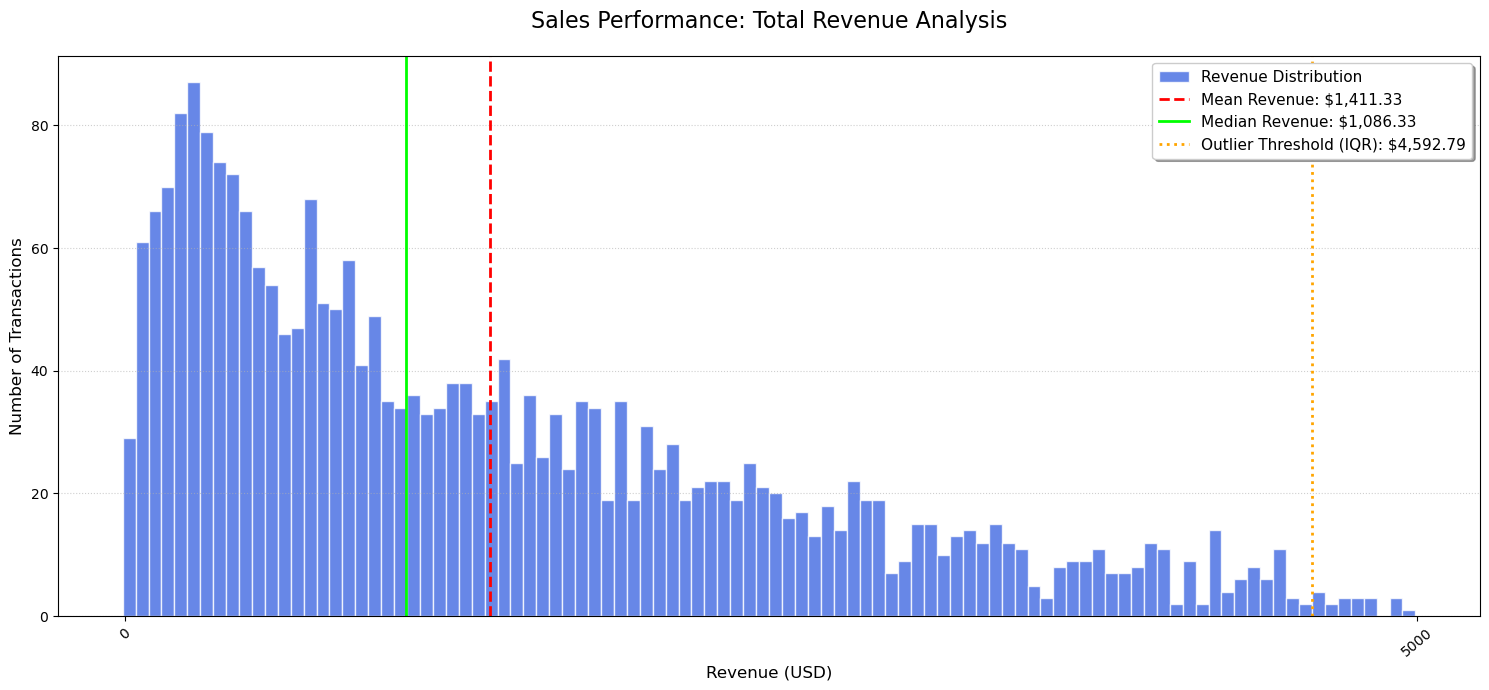

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Configuración de la figura y el histograma
plt.figure(figsize=(15, 7))
n, bins, patches = plt.hist(df['Total_Revenue'], bins=100, color='royalblue', 
                            edgecolor='white', alpha=0.8, label='Revenue Distribution')

# 2. Cálculos Estadísticos para las Líneas Verticales
mean_rev = df['Total_Revenue'].mean()
median_rev = df['Total_Revenue'].median()

# Cálculo del IQR para marcar el límite de Outliers (Slide 7)
q1 = df['Total_Revenue'].quantile(0.25)
q3 = df['Total_Revenue'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + (1.5 * iqr)

# 3. Dibujar Líneas Verticales (axvline) con Leyendas
plt.axvline(mean_rev, color='red', linestyle='--', linewidth=2, 
            label=f'Mean Revenue: ${mean_rev:,.2f}')
plt.axvline(median_rev, color='lime', linestyle='-', linewidth=2, 
            label=f'Median Revenue: ${median_rev:,.2f}')

# 4. Optimización de Ticks (Eje X)
# Dado que Revenue puede llegar a +$50,000 por los outliers, usamos pasos de 5,000
max_revenue = df['Total_Revenue'].max()
plt.xticks(np.arange(0, max_revenue + 5000, 5000), rotation=40, fontsize=10)

# 5. Formato Final y Leyenda
plt.title('Sales Performance: Total Revenue Analysis', fontsize=16, pad=20)
plt.xlabel('Revenue (USD)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

# Colocamos la leyenda en un cuadro con sombra para que resalte
plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=11)

plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

In [34]:
df.duplicated(keep = False).sum()

100